<a href="https://colab.research.google.com/github/samer-glitch/TADP-sec/blob/main/TADP-Sec%20Governance%20(Panel%20Results).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
import shutil
import os

uploaded = files.upload()

for filename in uploaded.keys():
    if filename.endswith(".csv"):
        shutil.move(filename, "/content/creditcard.csv")
        print(f"Uploaded and saved as: /content/creditcard.csv")

print(os.path.exists("/content/creditcard.csv"))

Saving creditcard.csv to creditcard.csv
Uploaded and saved as: /content/creditcard.csv
True


TADP-SEC v12.1 — COMBINED PUBLICATION FIGURE
✓ Results CSV          : /content/tadp_sec_results_v12_1/all_scenarios_results_comprehensive.csv
✓ Statistics directory: /content/tadp_sec_results_v12_1/stats
✓ Figure directory    : /content/tadp_sec_results_v12_1/figs/combined_publication_figure

Core scenarios found for Panels A and C:
  ✓ B0_Plain_FL: 5 seeds × 20 rounds
  ✓ B1_xMK_CKKS: 5 seeds × 20 rounds
  ✓ A1_TADP_admission_only: 5 seeds × 20 rounds
  ✓ T1_Plain_TADP: 5 seeds × 20 rounds
  ✓ T2_DF_KS_TADP: 5 seeds × 20 rounds
  ✓ T3_XMK_CKKS_TADP: 5 seeds × 20 rounds
  ✓ T4_SAMK_TADP: 3 seeds × 3 rounds

Panel B recovered admission outcomes:
  Auto accepted  : 6
  Review approved: 6
  Remediation    : 3
  Rejected       : 5


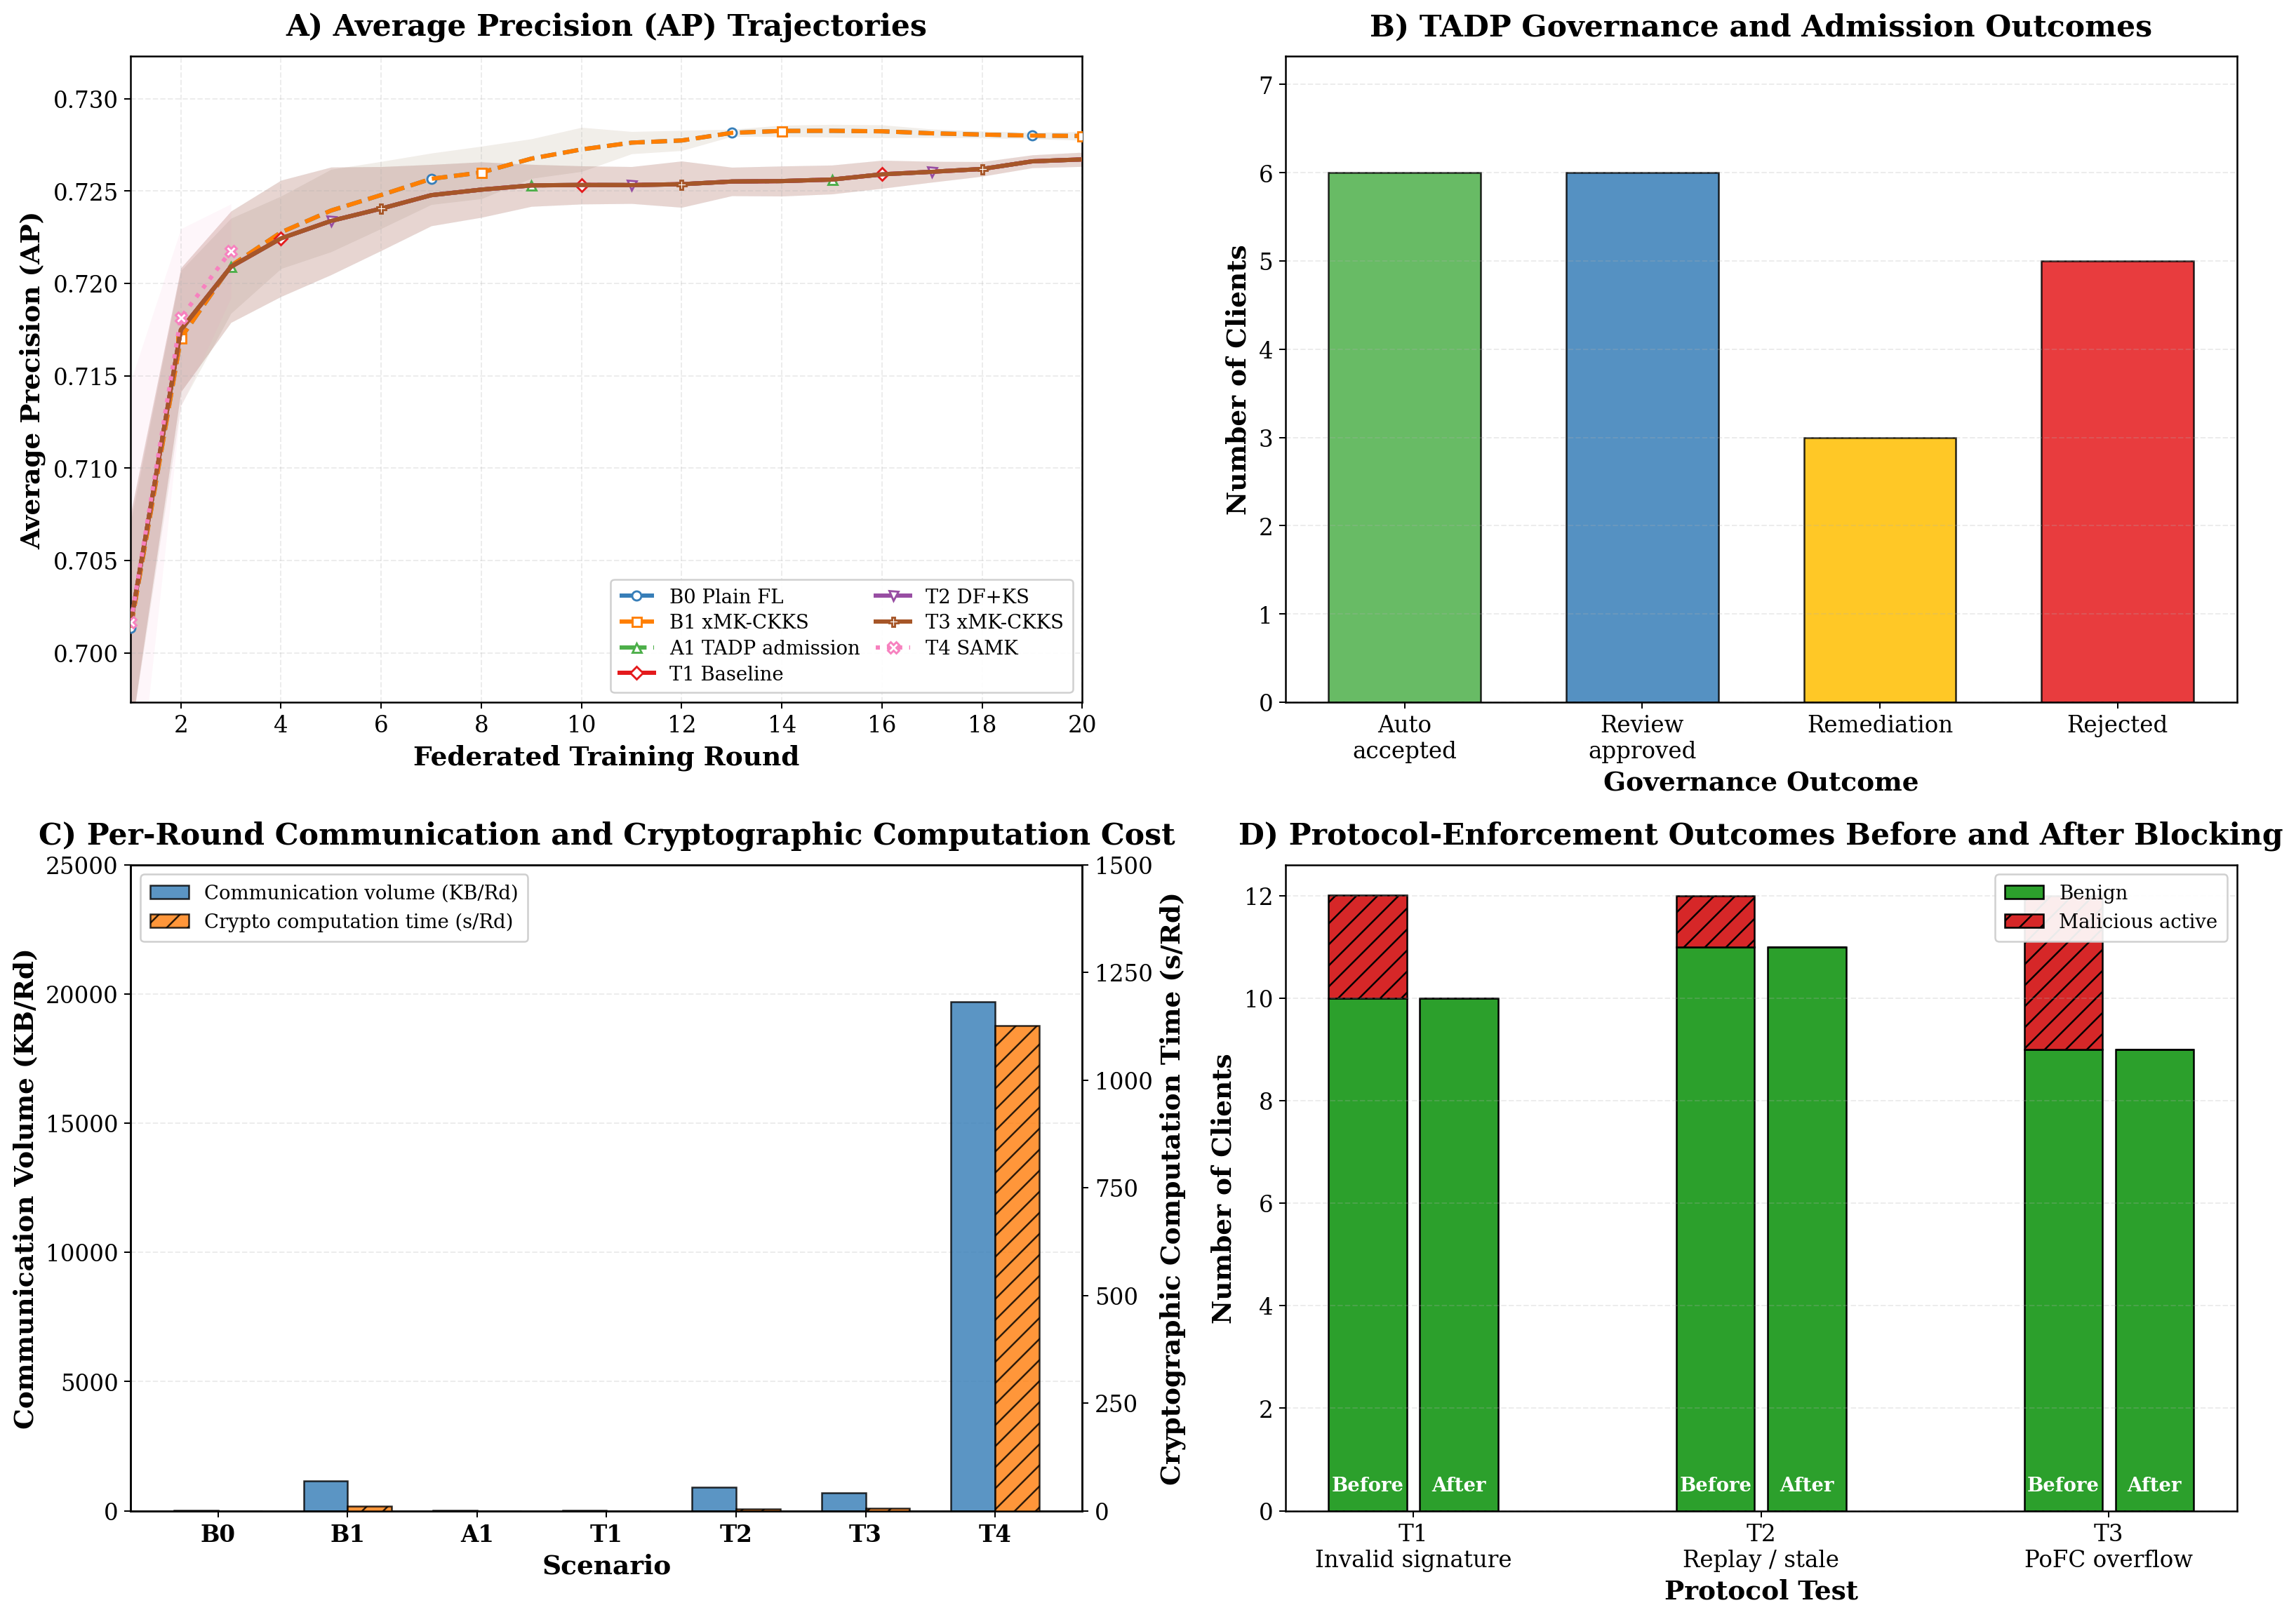


✓ 600-DPI PNG saved:
  /content/tadp_sec_results_v12_1/figs/combined_publication_figure/TADP_Sec_v12_1_Four_Panel_2x2_600dpi.png
✓ Vector PDF saved:
  /content/tadp_sec_results_v12_1/figs/combined_publication_figure/TADP_Sec_v12_1_Four_Panel_2x2_vector.pdf

✓ TADP-Sec v12.1 combined 2 × 2 publication figure generated.
✓ Panel A includes B0--T4 AP trajectories with staggered distinct markers.
✓ B0--T3 use 5 seeds × 20 rounds.
✓ T4 is shown over its separate 3-seed × 3-round feasibility horizon.
✓ Panel B reports TADP governance/admission outcomes.
✓ Panel C retains both metrics in one combined dual-axis panel: communication volume and cryptographic computation time.
✓ Panel C uses decimal KB (1 KB = 1000 bytes).
✓ Panel C uses separate left/right y-axes for communication volume and cryptographic computation time; the two units are not directly comparable.
✓ Panel D reports T1--T3 protocol-enforcement tests.
✓ No numerical annotations are placed above bars.
✓ Files included: 600-DPI PNG

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Starting automatic download of the ZIP archive containing the PNG and vector PDF...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ============================================================
# TADP-SEC v12.1
# COMBINED 2 × 2 PUBLICATION FIGURE
# ============================================================
#
# A) Average Precision (AP) Trajectories
#    - B0--T3: 5 seeds × 20 rounds
#    - T4:     3 seeds × 3 rounds (feasibility study)
#
# B) TADP Governance and Admission Outcomes
#
# C) Per-Round Communication and Cryptographic Computation Cost
#    - Includes B0--T4 in ONE combined dual-axis panel.
#    - Communication volume is shown as blue bars on the left y-axis
#      in decimal KB/Rd (1 KB = 1000 bytes).
#    - Cryptographic computation time is shown as orange hatched bars
#      on the right y-axis in s/Rd.
#    - The two bar series are offset side-by-side and use independent,
#      clearly labelled y-axes; their heights must be read against their
#      respective axes and are not directly comparable across units.
#
# D) Protocol-Enforcement Outcomes Before and After Blocking
#    - T1 invalid signature
#    - T2 replay/stale update
#    - T3 PoFC overflow
#
# IMPORTANT:
#   - DOES NOT rerun experiments.
#   - Uses saved v12.1 results only.
#   - T4 is explicitly included in Panels A and C.
#   - T4 AP trajectory stops naturally at round 3.
#   - Panel B can reconstruct admission outcomes from
#     admission_results.json.
#   - No numerical annotations above bars.
#   - Saves one 600-DPI PNG + one vector PDF.
#   - Automatically downloads a ZIP containing both.
#
# ============================================================


# ============================================================
# IMPORTS
# ============================================================

from pathlib import Path
import json
import zipfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

from scipy import stats
from matplotlib.ticker import MaxNLocator


# ============================================================
# GOOGLE COLAB DOWNLOAD SUPPORT
# ============================================================

try:
    from google.colab import files
    COLAB_AVAILABLE = True
except ImportError:
    COLAB_AVAILABLE = False


# ============================================================
# PATHS — v12.1
# ============================================================

OUT_PATH = Path(
    globals().get(
        "OUT_DIR",
        "tadp_sec_results_v12_1",
    )
)

STATS_PATH = Path(
    globals().get(
        "STATS_DIR",
        OUT_PATH / "stats",
    )
)

FIG_PATH = Path(
    globals().get(
        "FIG_DIR",
        OUT_PATH / "figs",
    )
)

RESULTS_CSV = (
    OUT_PATH
    / "all_scenarios_results_comprehensive.csv"
)

COMBINED_FIG_DIR = (
    FIG_PATH
    / "combined_publication_figure"
)

COMBINED_FIG_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


if not RESULTS_CSV.exists():
    raise FileNotFoundError(
        f"v12.1 results CSV not found:\n"
        f"{RESULTS_CSV.resolve()}\n\n"
        "Run TADP-Sec v12.1 first, then execute this cell."
    )


print("=" * 72)
print("TADP-SEC v12.1 — COMBINED PUBLICATION FIGURE")
print("=" * 72)
print(f"✓ Results CSV          : {RESULTS_CSV.resolve()}")
print(f"✓ Statistics directory: {STATS_PATH.resolve()}")
print(f"✓ Figure directory    : {COMBINED_FIG_DIR.resolve()}")
print("=" * 72)


# ============================================================
# LOAD SAVED RESULTS
# ============================================================

df = pd.read_csv(
    RESULTS_CSV
)

if "scenario" not in df.columns:
    raise KeyError(
        "Results CSV does not contain a 'scenario' column."
    )

df["scenario"] = (
    df["scenario"]
    .astype(str)
    .str.strip()
)


# ============================================================
# SCENARIO SELECTION
# ============================================================
#
# Do NOT filter Panels A/C only by reporting_group ==
# "main_comparative", because T4 is intentionally reported as
# a separate feasibility/reference profile.
#
# Explicitly include B0--T4.
# ============================================================

core_scenarios = {
    "B0_Plain_FL",
    "B1_xMK_CKKS",
    "A1_TADP_admission_only",
    "T1_Plain_TADP",
    "T2_DF_KS_TADP",
    "T3_XMK_CKKS_TADP",
    "T4_SAMK_TADP",
}

comparison_df = df.loc[
    df["scenario"].isin(core_scenarios)
].copy()


attack_scenarios = {
    "T1_TEST_SIGNATURE_ATTACK",
    "T2_TEST_REPLAY_ATTACK",
    "T3_TEST_POFC_ATTACK",
}

attack_df = df.loc[
    df["scenario"].isin(attack_scenarios)
].copy()


order = [
    "B0_Plain_FL",
    "B1_xMK_CKKS",
    "A1_TADP_admission_only",
    "T1_Plain_TADP",
    "T2_DF_KS_TADP",
    "T3_XMK_CKKS_TADP",
    "T4_SAMK_TADP",
]

present = [
    scenario
    for scenario in order
    if scenario in set(comparison_df["scenario"])
]


print("\nCore scenarios found for Panels A and C:")

for scenario in present:

    sub = comparison_df.loc[
        comparison_df["scenario"].eq(scenario)
    ]

    seeds = pd.to_numeric(
        sub.get("seed", pd.Series(dtype=float)),
        errors="coerce",
    ).dropna()

    rounds = pd.to_numeric(
        sub.get("round", pd.Series(dtype=float)),
        errors="coerce",
    ).dropna()

    n_seeds = (
        int(seeds.nunique())
        if not seeds.empty
        else 0
    )

    max_round = (
        int(rounds.max())
        if not rounds.empty
        else 0
    )

    print(
        f"  ✓ {scenario}: "
        f"{n_seeds} seeds × {max_round} rounds"
    )


if "T4_SAMK_TADP" not in present:
    raise RuntimeError(
        "T4_SAMK_TADP was not found in the saved v12.1 results. "
        "T4 cannot be displayed in Panels A and C."
    )


# ============================================================
# LABELS / VISUAL DEFINITIONS
# ============================================================

labels = {
    "B0_Plain_FL": "B0 Plain FL",
    "B1_xMK_CKKS": "B1 xMK-CKKS",
    "A1_TADP_admission_only": "A1 TADP admission",
    "T1_Plain_TADP": "T1 Baseline",
    "T2_DF_KS_TADP": "T2 DF+KS",
    "T3_XMK_CKKS_TADP": "T3 xMK-CKKS",
    "T4_SAMK_TADP": "T4 SAMK",
}


short_labels = {
    "B0_Plain_FL": "B0",
    "B1_xMK_CKKS": "B1",
    "A1_TADP_admission_only": "A1",
    "T1_Plain_TADP": "T1",
    "T2_DF_KS_TADP": "T2",
    "T3_XMK_CKKS_TADP": "T3",
    "T4_SAMK_TADP": "T4",
}


colors = {
    "B0_Plain_FL": "#377eb8",
    "B1_xMK_CKKS": "#ff7f00",
    "A1_TADP_admission_only": "#4daf4a",
    "T1_Plain_TADP": "#e41a1c",
    "T2_DF_KS_TADP": "#984ea3",
    "T3_XMK_CKKS_TADP": "#a65628",
    "T4_SAMK_TADP": "#f781bf",
}


styles = {
    "B0_Plain_FL": "--",
    "B1_xMK_CKKS": "--",
    "A1_TADP_admission_only": "-.",
    "T1_Plain_TADP": "-",
    "T2_DF_KS_TADP": "-",
    "T3_XMK_CKKS_TADP": "-",

    # T4 is visually distinguished because it uses the
    # separate 3-seed × 3-round feasibility design.
    "T4_SAMK_TADP": ":",
}


# ============================================================
# PUBLICATION TYPOGRAPHY
# ============================================================

TITLE_FS = 17
AXIS_FS = 15
TICK_FS = 13
LEGEND_FS = 11
ANNOT_FS = 11

LINE_WIDTH = 2.4
BAR_EDGE_WIDTH = 1.0

BYTES_PER_KB = 1000.0


mpl.rcParams.update({

    "font.family": "serif",
    "font.size": TICK_FS,

    "axes.titlesize": TITLE_FS,
    "axes.labelsize": AXIS_FS,

    "xtick.labelsize": TICK_FS,
    "ytick.labelsize": TICK_FS,

    "legend.fontsize": LEGEND_FS,

    "axes.linewidth": 1.0,
    "axes.titleweight": "bold",
    "axes.labelweight": "bold",

    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",

    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})


# ============================================================
# IDENTIFY AP COLUMN
# ============================================================

if "pr_auc" in comparison_df.columns:
    AP_COL = "pr_auc"

elif "average_precision" in comparison_df.columns:
    AP_COL = "average_precision"

elif "ap" in comparison_df.columns:
    AP_COL = "ap"

else:
    raise KeyError(
        "Could not identify AP column. "
        "Expected pr_auc, average_precision, or ap."
    )


# ============================================================
# CREATE 2 × 2 FIGURE
# ============================================================

fig, axes = plt.subplots(
    2,
    2,
    figsize=(18.0, 13.0),
    dpi=180,
)

axA = axes[0, 0]
axB = axes[0, 1]
axC = axes[1, 0]
axD = axes[1, 1]


# ============================================================
# A) AVERAGE PRECISION TRAJECTORIES
# ============================================================
#
# Several scenarios produce nearly identical AP trajectories.  The data are
# NOT displaced vertically.  Instead, each scenario receives a distinct
# marker and B0--T3 markers are staggered across rounds so coincident curves
# remain identifiable without changing their numerical values.
# ============================================================

all_ap = []

panel_a_markers = {
    "B0_Plain_FL": "o",
    "B1_xMK_CKKS": "s",
    "A1_TADP_admission_only": "^",
    "T1_Plain_TADP": "D",
    "T2_DF_KS_TADP": "v",
    "T3_XMK_CKKS_TADP": "P",
    "T4_SAMK_TADP": "X",
}

# Six stagger positions are sufficient for the six 20-round B0--T3 profiles.
# T4 is only three rounds, so every T4 point is marked.
main_marker_offsets = {
    "B0_Plain_FL": 0,
    "B1_xMK_CKKS": 1,
    "A1_TADP_admission_only": 2,
    "T1_Plain_TADP": 3,
    "T2_DF_KS_TADP": 4,
    "T3_XMK_CKKS_TADP": 5,
}

for scenario in present:

    sub = comparison_df.loc[
        comparison_df["scenario"].eq(scenario)
    ].copy()

    if sub.empty:
        continue

    round_stats = (
        sub.groupby("round")[AP_COL]
        .agg(["mean", "std", "count"])
        .reset_index()
        .sort_values("round")
    )

    round_stats["std"] = (
        round_stats["std"]
        .fillna(0.0)
    )

    round_stats["se"] = (
        round_stats["std"]
        /
        np.sqrt(
            round_stats["count"]
            .clip(lower=1)
        )
    )

    round_stats["tcrit"] = (
        round_stats["count"]
        .apply(
            lambda n:
                float(
                    stats.t.ppf(
                        0.975,
                        df=int(n) - 1,
                    )
                )
                if int(n) > 1
                else 0.0
        )
    )

    round_stats["ci"] = (
        round_stats["tcrit"]
        *
        round_stats["se"]
    )

    if scenario == "T4_SAMK_TADP":
        markevery = 1
        marker_size = 6.2
    else:
        markevery = (
            main_marker_offsets.get(scenario, 0),
            6,
        )
        marker_size = 5.2

    axA.plot(
        round_stats["round"],
        round_stats["mean"],
        color=colors[scenario],
        linestyle=styles[scenario],
        linewidth=LINE_WIDTH,
        marker=panel_a_markers.get(scenario, "o"),
        markevery=markevery,
        markersize=marker_size,
        markerfacecolor="white",
        markeredgecolor=colors[scenario],
        markeredgewidth=1.15,
        label=labels[scenario],
        zorder=3,
    )

    if int(round_stats["count"].max()) > 1:

        axA.fill_between(
            round_stats["round"],
            round_stats["mean"] - round_stats["ci"],
            round_stats["mean"] + round_stats["ci"],
            color=colors[scenario],
            alpha=0.065,
            linewidth=0,
            zorder=1,
        )

    all_ap.extend(
        round_stats["mean"].tolist()
    )


axA.set_title(
    "A) Average Precision (AP) Trajectories",
    fontsize=TITLE_FS,
    fontweight="bold",
    pad=12,
)

axA.set_xlabel(
    "Federated Training Round",
    fontsize=AXIS_FS,
    fontweight="bold",
)

axA.set_ylabel(
    "Average Precision (AP)",
    fontsize=AXIS_FS,
    fontweight="bold",
)


axA.tick_params(
    axis="both",
    labelsize=TICK_FS,
)


axA.grid(
    True,
    alpha=0.23,
    linestyle="--",
    linewidth=0.8,
)


if all_ap:

    low = min(all_ap)
    high = max(all_ap)

    margin = max(
        0.002,
        (high - low) * 0.15,
    )

    axA.set_ylim(
        max(0.0, low - margin),
        min(1.0, high + margin),
    )


round_numeric = pd.to_numeric(
    comparison_df["round"],
    errors="coerce",
).dropna()


if not round_numeric.empty:

    max_round = int(
        round_numeric.max()
    )

    if max_round <= 1:

        axA.set_xlim(
            0.75,
            1.25,
        )

        axA.set_xticks(
            [1]
        )

    else:

        # B0--T3 continue to 20 rounds.
        # T4 naturally stops after round 3.
        axA.set_xlim(
            1,
            max_round,
        )

        axA.xaxis.set_major_locator(
            MaxNLocator(
                integer=True,
                nbins=min(
                    10,
                    max_round,
                ),
            )
        )


axA.legend(
    loc="lower right",
    ncol=2,
    fontsize=LEGEND_FS,
    frameon=True,
    framealpha=0.92,
    borderpad=0.45,
    labelspacing=0.35,
    handlelength=1.8,
    columnspacing=0.8,
)


# ============================================================
# B) GOVERNANCE / ADMISSION OUTCOMES
# ============================================================

admission_stats = {}


# Prefer live experiment statistics when available.
experiment_obj = globals().get(
    "experiment",
    None,
)


if experiment_obj is not None:

    live_stats = getattr(
        experiment_obj,
        "admission_stats",
        None,
    )

    if isinstance(
        live_stats,
        dict,
    ):

        live_by_outcome = (
            live_stats.get(
                "by_outcome",
                {},
            )
            or {}
        )

        if live_by_outcome:
            admission_stats = dict(
                live_stats
            )


# ------------------------------------------------------------
# Fallback to saved admission_results.json
# ------------------------------------------------------------

if not admission_stats:

    admission_json_path = (
        STATS_PATH
        / "admission_results.json"
    )

    if not admission_json_path.exists():

        raise FileNotFoundError(
            "Panel B cannot find admission_results.json:\n"
            f"{admission_json_path.resolve()}"
        )


    with open(
        admission_json_path,
        "r",
        encoding="utf-8",
    ) as f:

        admission_payload = json.load(
            f
        )


    if (
        isinstance(admission_payload, dict)
        and isinstance(
            admission_payload.get("admission_results"),
            dict,
        )
    ):

        candidate_records = (
            admission_payload[
                "admission_results"
            ]
        )

    else:

        candidate_records = admission_payload


    client_records = {}


    if isinstance(
        candidate_records,
        dict,
    ):

        for client_id, record in (
            candidate_records.items()
        ):

            if not isinstance(
                record,
                dict,
            ):
                continue

            if (
                "admitted" in record
                or "review_outcome" in record
                or "outcome" in record
            ):

                client_records[
                    str(client_id)
                ] = record


    if not client_records:

        raise RuntimeError(
            "Panel B found admission_results.json, "
            "but no client admission records were reconstructed."
        )


    by_outcome_rebuilt = {}
    admitted_count = 0


    for _, record in (
        client_records.items()
    ):

        if bool(
            record.get(
                "admitted",
                False,
            )
        ):
            admitted_count += 1


        outcome = str(
            record.get(
                "review_outcome",
                record.get(
                    "outcome",
                    "UNKNOWN",
                ),
            )
        )


        by_outcome_rebuilt[
            outcome
        ] = (
            by_outcome_rebuilt.get(
                outcome,
                0,
            )
            + 1
        )


    total_count = len(
        client_records
    )


    admission_stats = {
        "total": total_count,
        "admitted": admitted_count,
        "not_admitted":
            total_count
            - admitted_count,
        "by_outcome":
            by_outcome_rebuilt,
    }


by_outcome = (
    admission_stats.get(
        "by_outcome",
        {},
    )
    or {}
)


auto_accept = int(
    by_outcome.get(
        "TADP_DIRECT_AUTO_ACCEPT",
        0,
    )
)


review_approve = int(
    by_outcome.get(
        "TADP_REVIEW_ACCEPT_CRITICAL_PROFILE_SUFFICIENT",
        0,
    )
)


remediate = (

    int(
        by_outcome.get(
            "TADP_CRITICAL_DIMENSION_REMEDIATION",
            0,
        )
    )

    +

    int(
        by_outcome.get(
            "TADP_CRITICAL_PROFILE_REMEDIATION",
            0,
        )
    )

    +

    int(
        by_outcome.get(
            "TADP_REVIEW_REMEDIATE_CRITICAL_PROFILE_BELOW_REVIEW_THRESHOLD",
            0,
        )
    )
)


rejected = int(
    by_outcome.get(
        "TADP_AUTO_REJECT_BELOW_LOWER_THRESHOLD",
        0,
    )
)


other_quarantine = (

    int(
        by_outcome.get(
            "TADP_EVIDENCE_INTEGRITY_UNRESOLVED",
            0,
        )
    )

    +

    int(
        by_outcome.get(
            "CLIENT_REVOKED",
            0,
        )
    )
)


governance_labels = [
    "Auto\naccepted",
    "Review\napproved",
    "Remediation",
    "Rejected",
]


governance_values = [
    auto_accept,
    review_approve,
    remediate,
    rejected,
]


governance_colors = [
    "#4daf4a",
    "#377eb8",
    "#ffbf00",
    "#e41a1c",
]


if other_quarantine > 0:

    governance_labels.append(
        "Other\nquarantine"
    )

    governance_values.append(
        other_quarantine
    )

    governance_colors.append(
        "#984ea3"
    )


if sum(governance_values) == 0:

    print(
        "\nAvailable admission outcomes:"
    )

    for key, value in sorted(
        by_outcome.items()
    ):

        print(
            f"  {key}: {value}"
        )

    raise RuntimeError(
        "Panel B admission values are all zero."
    )


print(
    "\nPanel B recovered admission outcomes:"
)

print(
    f"  Auto accepted  : {auto_accept}"
)

print(
    f"  Review approved: {review_approve}"
)

print(
    f"  Remediation    : {remediate}"
)

print(
    f"  Rejected       : {rejected}"
)


xB = np.arange(
    len(governance_values)
)


axB.bar(
    xB,
    governance_values,
    width=0.64,
    color=governance_colors,
    edgecolor="black",
    linewidth=BAR_EDGE_WIDTH,
    alpha=0.85,
)


axB.set_title(
    "B) TADP Governance and Admission Outcomes",
    fontsize=TITLE_FS,
    fontweight="bold",
    pad=12,
)

axB.set_xlabel(
    "Governance Outcome",
    fontsize=AXIS_FS,
    fontweight="bold",
)

axB.set_ylabel(
    "Number of Clients",
    fontsize=AXIS_FS,
    fontweight="bold",
)


axB.set_xticks(
    xB
)

axB.set_xticklabels(
    governance_labels,
    fontsize=TICK_FS,
)


axB.tick_params(
    axis="y",
    labelsize=TICK_FS,
)


axB.yaxis.set_major_locator(
    MaxNLocator(
        integer=True
    )
)


axB.grid(
    True,
    axis="y",
    alpha=0.23,
    linestyle="--",
    linewidth=0.8,
)


axB.set_ylim(
    0,
    max(
        1,
        max(governance_values)
    )
    * 1.22,
)


# ============================================================
# C) PER-ROUND COMMUNICATION AND CRYPTOGRAPHIC COMPUTATION COST
# ============================================================
#
# One combined Panel C is retained.
#
# C1) Communication volume
#     C_Rd = C_uplink + C_downlink
#     Unit: KB/Rd, using decimal KB (1 KB = 1000 bytes).
#     This is generated protocol-object byte volume.  It is NOT
#     communication time and does not measure transport latency.
#
# C2) Cryptographic computation time
#     T_crypto = T_protection/encryption
#              + T_protected aggregation/finalization
#              + T_authorized recovery/decryption
#     Unit: s/Rd.
#     It excludes local model training, validation/test evaluation,
#     and network-transfer latency.
#
# IMPORTANT VISUAL DESIGN:
# Communication is encoded as BARS; crypto time is encoded as a LINE with
# markers.  They retain separate y-axes because the quantities have different
# units.  This avoids the former side-by-side-bar illusion in which T4 looked
# as if the communication value and crypto-time value were numerically equal.
# ============================================================

communication_kb = []
crypto_seconds = []
cost_labels = []


for scenario in present:

    sub = comparison_df.loc[
        comparison_df["scenario"].eq(
            scenario
        )
    ].copy()

    # --------------------------------------------------------
    # COMMUNICATION VOLUME / Rd
    # --------------------------------------------------------

    if "comm_total_bytes" in sub.columns:

        comm = pd.to_numeric(
            sub[
                "comm_total_bytes"
            ],
            errors="coerce",
        ).dropna()

    else:

        up = pd.to_numeric(
            sub.get(
                "comm_up_bytes",
                pd.Series(
                    0.0,
                    index=sub.index,
                ),
            ),
            errors="coerce",
        ).fillna(0.0)

        down = pd.to_numeric(
            sub.get(
                "comm_down_bytes",
                pd.Series(
                    0.0,
                    index=sub.index,
                ),
            ),
            errors="coerce",
        ).fillna(0.0)

        comm = up + down

    # --------------------------------------------------------
    # CRYPTOGRAPHIC COMPUTATION TIME / Rd
    # --------------------------------------------------------
    # Prefer the v12.1 explicit complete crypto path.
    # --------------------------------------------------------

    if "crypto_path_total_ms" in sub.columns:

        crypto = pd.to_numeric(
            sub[
                "crypto_path_total_ms"
            ],
            errors="coerce",
        ).dropna()

    elif "crypto_total_overhead_ms" in sub.columns:

        crypto = pd.to_numeric(
            sub[
                "crypto_total_overhead_ms"
            ],
            errors="coerce",
        ).dropna()

    elif "crypto_overhead_ms" in sub.columns:

        crypto = pd.to_numeric(
            sub[
                "crypto_overhead_ms"
            ],
            errors="coerce",
        ).dropna()

    elif "crypto_operation_ms" in sub.columns:

        crypto = pd.to_numeric(
            sub[
                "crypto_operation_ms"
            ],
            errors="coerce",
        ).dropna()

    else:

        crypto = pd.Series(
            0.0,
            index=sub.index,
        )

    communication_kb.append(
        float(
            comm.mean()
        ) / BYTES_PER_KB
        if len(comm) > 0
        else 0.0
    )

    crypto_seconds.append(
        float(
            crypto.mean()
        ) / 1000.0
        if len(crypto) > 0
        else 0.0
    )

    cost_labels.append(
        short_labels[
            scenario
        ]
    )


xC = np.arange(
    len(cost_labels)
)

# Two offset bar series are retained in the same Panel C.
# Each series is read against its own labelled y-axis.
bar_width_C = 0.34

axC2 = axC.twinx()

communication_bars = axC.bar(
    xC - bar_width_C / 2,
    communication_kb,
    bar_width_C,
    color="#377eb8",
    alpha=0.82,
    edgecolor="black",
    linewidth=BAR_EDGE_WIDTH,
    label="Communication volume (KB/Rd)",
    zorder=2,
)

crypto_bars = axC2.bar(
    xC + bar_width_C / 2,
    crypto_seconds,
    bar_width_C,
    color="#ff7f0e",
    alpha=0.82,
    edgecolor="black",
    linewidth=BAR_EDGE_WIDTH,
    hatch="//",
    label="Crypto computation time (s/Rd)",
    zorder=3,
)

axC.set_title(
    "C) Per-Round Communication and Cryptographic Computation Cost",
    fontsize=TITLE_FS,
    fontweight="bold",
    pad=12,
)

axC.set_xlabel(
    "Scenario",
    fontsize=AXIS_FS,
    fontweight="bold",
)

axC.set_ylabel(
    "Communication Volume (KB/Rd)",
    fontsize=AXIS_FS,
    fontweight="bold",
)

axC2.set_ylabel(
    "Cryptographic Computation Time (s/Rd)",
    fontsize=AXIS_FS,
    fontweight="bold",
)

axC.set_xticks(
    xC
)

axC.set_xticklabels(
    cost_labels,
    fontsize=TICK_FS,
    fontweight="bold",
)

axC.tick_params(
    axis="y",
    labelsize=TICK_FS,
)

axC2.tick_params(
    axis="y",
    labelsize=TICK_FS,
)

axC.grid(
    True,
    axis="y",
    alpha=0.23,
    linestyle="--",
    linewidth=0.8,
    zorder=0,
)


def _nice_upper_limit(values, minimum, padding=1.12):
    """
    Return a rounded publication-friendly upper limit with headroom.

    Both axes use the SAME padding rule, then round independently to a
    human-readable ceiling appropriate for their own units.  This avoids
    forcing each maximum to exactly the same fractional height.
    """

    finite = [
        float(v)
        for v in values
        if np.isfinite(v)
    ]

    maximum = max(finite) if finite else float(minimum)
    raw = max(float(minimum), maximum * float(padding))

    if raw <= 0:
        return float(minimum)

    exponent = 10.0 ** np.floor(np.log10(raw))
    fraction = raw / exponent

    nice_fractions = [
        1.0,
        1.25,
        1.5,
        2.0,
        2.5,
        3.0,
        4.0,
        5.0,
        7.5,
        10.0,
    ]

    nice_fraction = next(
        (
            candidate
            for candidate in nice_fractions
            if fraction <= candidate + 1e-12
        ),
        10.0,
    )

    return float(
        nice_fraction
        * exponent
    )


communication_upper = _nice_upper_limit(
    communication_kb,
    minimum=1.0,
)

crypto_upper = _nice_upper_limit(
    crypto_seconds,
    minimum=0.1,
)

axC.set_ylim(
    0,
    communication_upper,
)

axC2.set_ylim(
    0,
    crypto_upper,
)

axC.yaxis.set_major_locator(
    MaxNLocator(nbins=6)
)

axC2.yaxis.set_major_locator(
    MaxNLocator(nbins=6)
)

# One legend with two distinct bar styles.
# Blue solid bars = communication volume; orange hatched bars = crypto time.
axC.legend(
    [
        communication_bars,
        crypto_bars,
    ],
    [
        "Communication volume (KB/Rd)",
        "Crypto computation time (s/Rd)",
    ],
    loc="upper left",
    fontsize=LEGEND_FS,
    frameon=True,
    framealpha=0.94,
    borderpad=0.5,
)

# ------------------------------------------------------------
# Panel C intentionally contains no equation/definition box.
# The legend and axis labels identify the two independent metrics.
# Both are bars, but they use different units and independent y-axes.
# ------------------------------------------------------------

# ============================================================
# D) PROTOCOL ENFORCEMENT
# ============================================================

attack_order = [
    "T1_TEST_SIGNATURE_ATTACK",
    "T2_TEST_REPLAY_ATTACK",
    "T3_TEST_POFC_ATTACK",
]


attack_present = [
    scenario
    for scenario in attack_order
    if scenario in set(
        attack_df["scenario"]
    )
]


if not attack_present:

    axD.text(
        0.5,
        0.5,
        "No protocol-enforcement scenarios recorded",
        ha="center",
        va="center",
        fontsize=AXIS_FS,
    )

    axD.axis(
        "off"
    )


else:

    group_x = (
        np.arange(
            len(attack_present)
        )
        * 3.2
    )


    before_x = (
        group_x - 0.42
    )

    after_x = (
        group_x + 0.42
    )

    width_D = 0.72


    benign_before = []
    malicious_before = []

    benign_after = []
    malicious_after = []

    captions = []


    caption_map = {

        "T1_TEST_SIGNATURE_ATTACK":
            "T1\nInvalid signature",

        "T2_TEST_REPLAY_ATTACK":
            "T2\nReplay / stale",

        "T3_TEST_POFC_ATTACK":
            "T3\nPoFC overflow",
    }


    for scenario in attack_present:

        sub = attack_df.loc[
            attack_df["scenario"].eq(
                scenario
            )
        ]


        initial_mal = int(
            pd.to_numeric(
                sub.get(
                    "initial_malicious_count",
                    pd.Series(
                        0,
                        index=sub.index,
                    ),
                ),
                errors="coerce",
            )
            .fillna(0)
            .max()
        )


        initial_benign = int(
            pd.to_numeric(
                sub.get(
                    "initial_benign_count",
                    pd.Series(
                        0,
                        index=sub.index,
                    ),
                ),
                errors="coerce",
            )
            .fillna(0)
            .max()
        )


        banned_mal = int(
            pd.to_numeric(
                sub.get(
                    "malicious_clients_banned_total",
                    pd.Series(
                        0,
                        index=sub.index,
                    ),
                ),
                errors="coerce",
            )
            .fillna(0)
            .max()
        )


        banned_ben = int(
            pd.to_numeric(
                sub.get(
                    "benign_clients_banned_total",
                    pd.Series(
                        0,
                        index=sub.index,
                    ),
                ),
                errors="coerce",
            )
            .fillna(0)
            .max()
        )


        benign_before.append(
            initial_benign
        )

        malicious_before.append(
            initial_mal
        )


        benign_after.append(
            max(
                0,
                initial_benign
                - banned_ben,
            )
        )


        malicious_after.append(
            max(
                0,
                initial_mal
                - banned_mal,
            )
        )


        captions.append(
            caption_map[
                scenario
            ]
        )


    axD.bar(
        before_x,
        benign_before,
        width_D,
        color="#2ca02c",
        edgecolor="black",
        linewidth=BAR_EDGE_WIDTH,
        label="Benign",
    )


    axD.bar(
        before_x,
        malicious_before,
        width_D,
        bottom=benign_before,
        color="#d62728",
        edgecolor="black",
        linewidth=BAR_EDGE_WIDTH,
        hatch="//",
        label="Malicious active",
    )


    axD.bar(
        after_x,
        benign_after,
        width_D,
        color="#2ca02c",
        edgecolor="black",
        linewidth=BAR_EDGE_WIDTH,
    )


    axD.bar(
        after_x,
        malicious_after,
        width_D,
        bottom=benign_after,
        color="#d62728",
        edgecolor="black",
        linewidth=BAR_EDGE_WIDTH,
        hatch="//",
    )


    axD.set_xticks(
        group_x
    )


    axD.set_xticklabels(
        captions,
        fontsize=TICK_FS,
    )


    # Only Before / After labels are retained.
    # No numerical annotations above bars.
    for x0, x1 in zip(
        before_x,
        after_x,
    ):

        axD.text(
            x0,
            0.30,
            "Before",
            ha="center",
            va="bottom",
            fontsize=ANNOT_FS,
            color="white",
            fontweight="bold",
        )


        axD.text(
            x1,
            0.30,
            "After",
            ha="center",
            va="bottom",
            fontsize=ANNOT_FS,
            color="white",
            fontweight="bold",
        )


    axD.set_title(
        "D) Protocol-Enforcement Outcomes Before and After Blocking",
        fontsize=TITLE_FS,
        fontweight="bold",
        pad=12,
    )


    axD.set_xlabel(
        "Protocol Test",
        fontsize=AXIS_FS,
        fontweight="bold",
    )


    axD.set_ylabel(
        "Number of Clients",
        fontsize=AXIS_FS,
        fontweight="bold",
    )


    axD.tick_params(
        axis="y",
        labelsize=TICK_FS,
    )


    axD.yaxis.set_major_locator(
        MaxNLocator(
            integer=True
        )
    )


    axD.grid(
        True,
        axis="y",
        alpha=0.23,
        linestyle="--",
        linewidth=0.8,
    )


    axD.legend(
        loc="upper right",
        fontsize=LEGEND_FS,
        frameon=True,
        framealpha=0.92,
        borderpad=0.5,
    )


# ============================================================
# GLOBAL SPACING
# ============================================================

fig.subplots_adjust(
    left=0.075,
    right=0.94,
    bottom=0.075,
    top=0.94,
    wspace=0.30,
    hspace=0.34,
)


# ============================================================
# SAVE v12.1 COMBINED FIGURE
# ============================================================

PNG_PATH = (
    COMBINED_FIG_DIR
    / "TADP_Sec_v12_1_Four_Panel_2x2_600dpi.png"
)

PDF_PATH = (
    COMBINED_FIG_DIR
    / "TADP_Sec_v12_1_Four_Panel_2x2_vector.pdf"
)


fig.savefig(
    PNG_PATH,
    dpi=600,
    bbox_inches="tight",
    pad_inches=0.12,
    facecolor="white",
    transparent=False,
)


fig.savefig(
    PDF_PATH,
    format="pdf",
    bbox_inches="tight",
    pad_inches=0.12,
    facecolor="white",
    transparent=False,
)


plt.show()


print(
    f"\n✓ 600-DPI PNG saved:\n"
    f"  {PNG_PATH.resolve()}"
)

print(
    f"✓ Vector PDF saved:\n"
    f"  {PDF_PATH.resolve()}"
)


# ============================================================
# CREATE v12.1 FIGURE DOWNLOAD ZIP
# ============================================================

ZIP_PATH = Path(
    "/content/"
    "TADP_Sec_v12_1_Four_Panel_2x2_Figure.zip"
)


if ZIP_PATH.exists():
    ZIP_PATH.unlink()


with zipfile.ZipFile(
    ZIP_PATH,
    "w",
    compression=zipfile.ZIP_DEFLATED,
) as zf:

    zf.write(
        PNG_PATH,
        arcname=PNG_PATH.name,
    )

    zf.write(
        PDF_PATH,
        arcname=PDF_PATH.name,
    )


print(
    "\n============================================================"
)

print(
    "✓ TADP-Sec v12.1 combined 2 × 2 "
    "publication figure generated."
)

print(
    "✓ Panel A includes B0--T4 AP trajectories with staggered distinct markers."
)

print(
    "✓ B0--T3 use 5 seeds × 20 rounds."
)

print(
    "✓ T4 is shown over its separate "
    "3-seed × 3-round feasibility horizon."
)

print(
    "✓ Panel B reports TADP governance/admission outcomes."
)

print(
    "✓ Panel C retains both metrics in one combined dual-axis panel: "
    "communication volume and cryptographic computation time."
)

print(
    "✓ Panel C uses decimal KB (1 KB = 1000 bytes)."
)

print(
    "✓ Panel C uses separate left/right y-axes for communication volume "
    "and cryptographic computation time; the two units are not directly comparable."
)

print(
    "✓ Panel D reports T1--T3 protocol-enforcement tests."
)

print(
    "✓ No numerical annotations are placed above bars."
)

print(
    "✓ Files included: 600-DPI PNG + vector PDF."
)

print(
    f"✓ ZIP archive: {ZIP_PATH}"
)

print(
    "============================================================"
)


# ============================================================
# AUTOMATIC DOWNLOAD — FIGURE + ARCHIVE
# ============================================================

if COLAB_AVAILABLE:

    print(
        "\nStarting automatic download of the 600-DPI PNG figure..."
    )

    # Direct figure download
    files.download(str(PNG_PATH))

    print(
        "Starting automatic download of the ZIP archive "
        "containing the PNG and vector PDF..."
    )

    # Archive contains both publication formats
    files.download(str(ZIP_PATH))

else:

    print(
        "\nNot running in Google Colab.\n"
        f"600-DPI PNG: {PNG_PATH}\n"
        f"Vector PDF : {PDF_PATH}\n"
        f"ZIP archive: {ZIP_PATH}"
    )
